# 1. Exploratory Data Analysis

This notebook explores the **Online Shoppers Purchasing Intention Dataset** to understand feature distributions, class balance, correlations, and relationships with the target variable (`Revenue`).

> **Colab Setup** — La cella seguente configura automaticamente l'ambiente Google Colab. 
Se stai eseguendo il notebook in locale, verrà saltata automaticamente.

In [ ]:
# ── Colab Setup ──────────────────────────────────────────────
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('ecommerce-intention'):
        !git clone -q https://github.com/davidemeta/Predicting-Online-Shoppers-Purchasing-Intention.git ecommerce-intention
    os.chdir('ecommerce-intention/notebooks')
    !pip install -q -r ../requirements.txt
    print('Colab setup completato')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [2]:
# Load dataset
data_path = Path('../data/online_shoppers_intention.csv')
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Dataset shape: (12330, 18)
Rows: 12,330  |  Columns: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 1.1 Target Distribution

The target variable `Revenue` indicates whether the session resulted in a purchase.

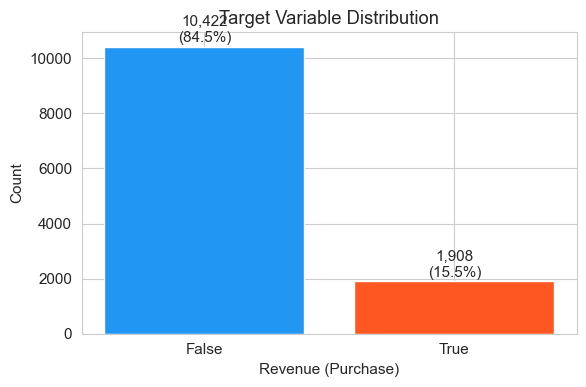


Class imbalance ratio: 5.5 : 1


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Revenue'].value_counts()
colors = ['#2196F3', '#FF5722']
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')

# Add percentage labels
total = len(df)
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Revenue (Purchase)')
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio: {counts[False]/counts[True]:.1f} : 1')

## 1.2 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print('\n No missing values found in the dataset.')
else:
    print(f'\n Total missing values: {missing.sum()}')

Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []

 No missing values found in the dataset.


## 1.3 Numerical Features Distribution

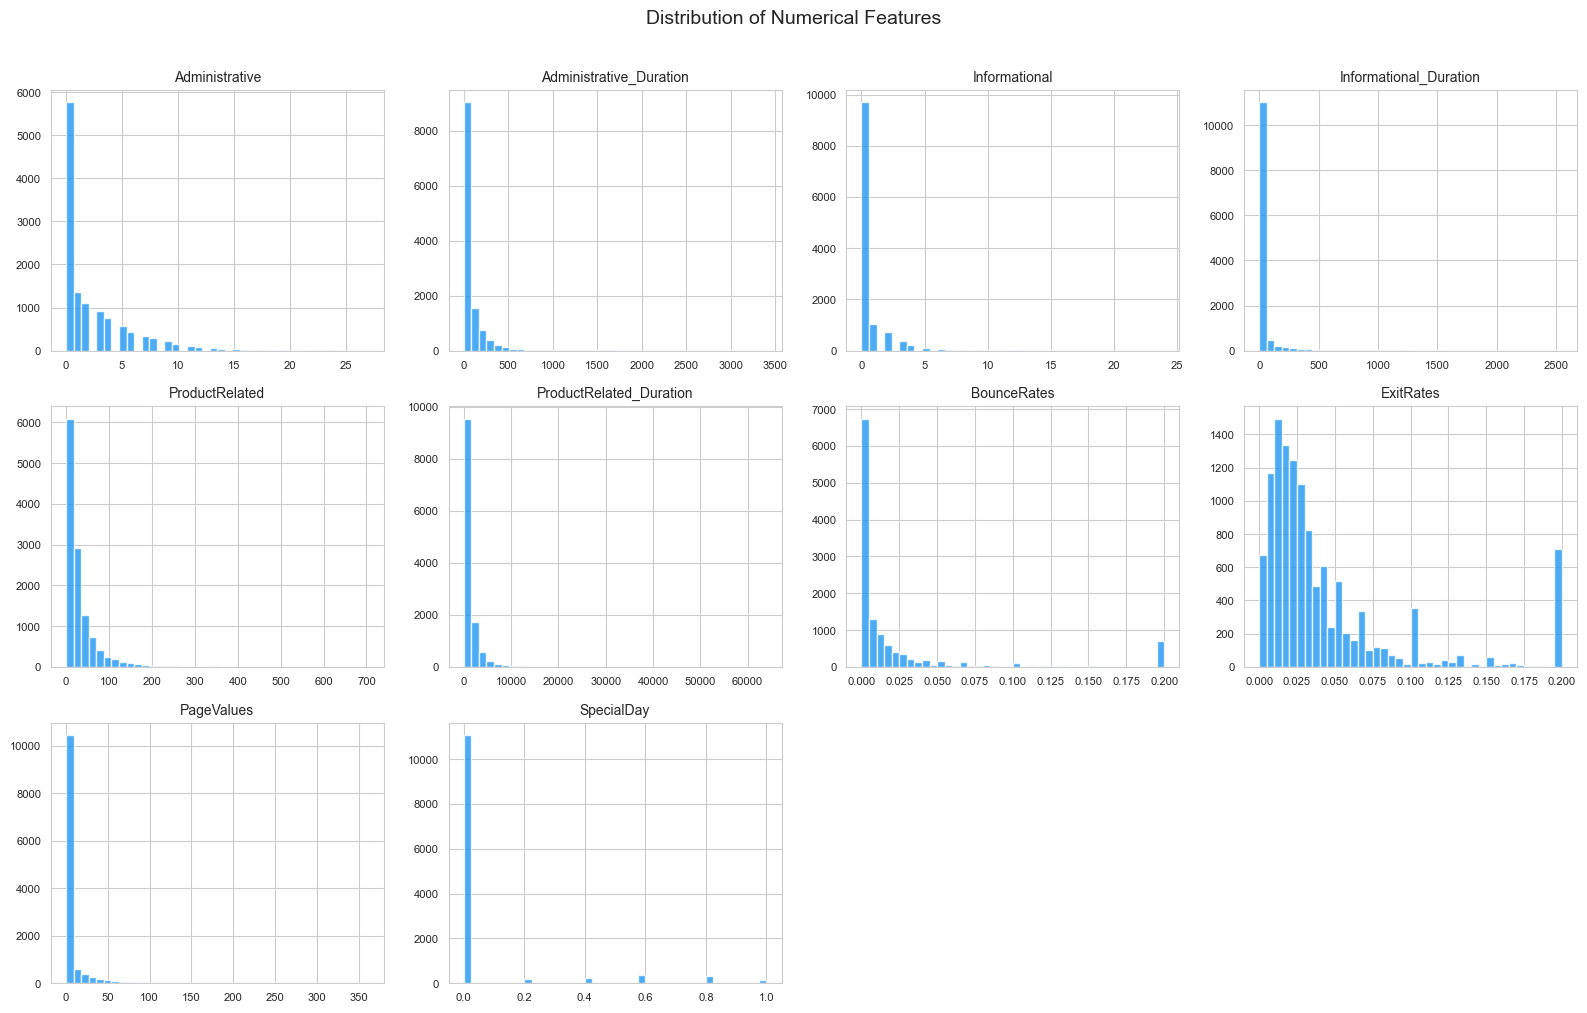

In [7]:
numerical_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.4 Categorical Features

/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/2802790718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='Set2')
/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/2802790718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='Set2')
/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/2802790718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], pa

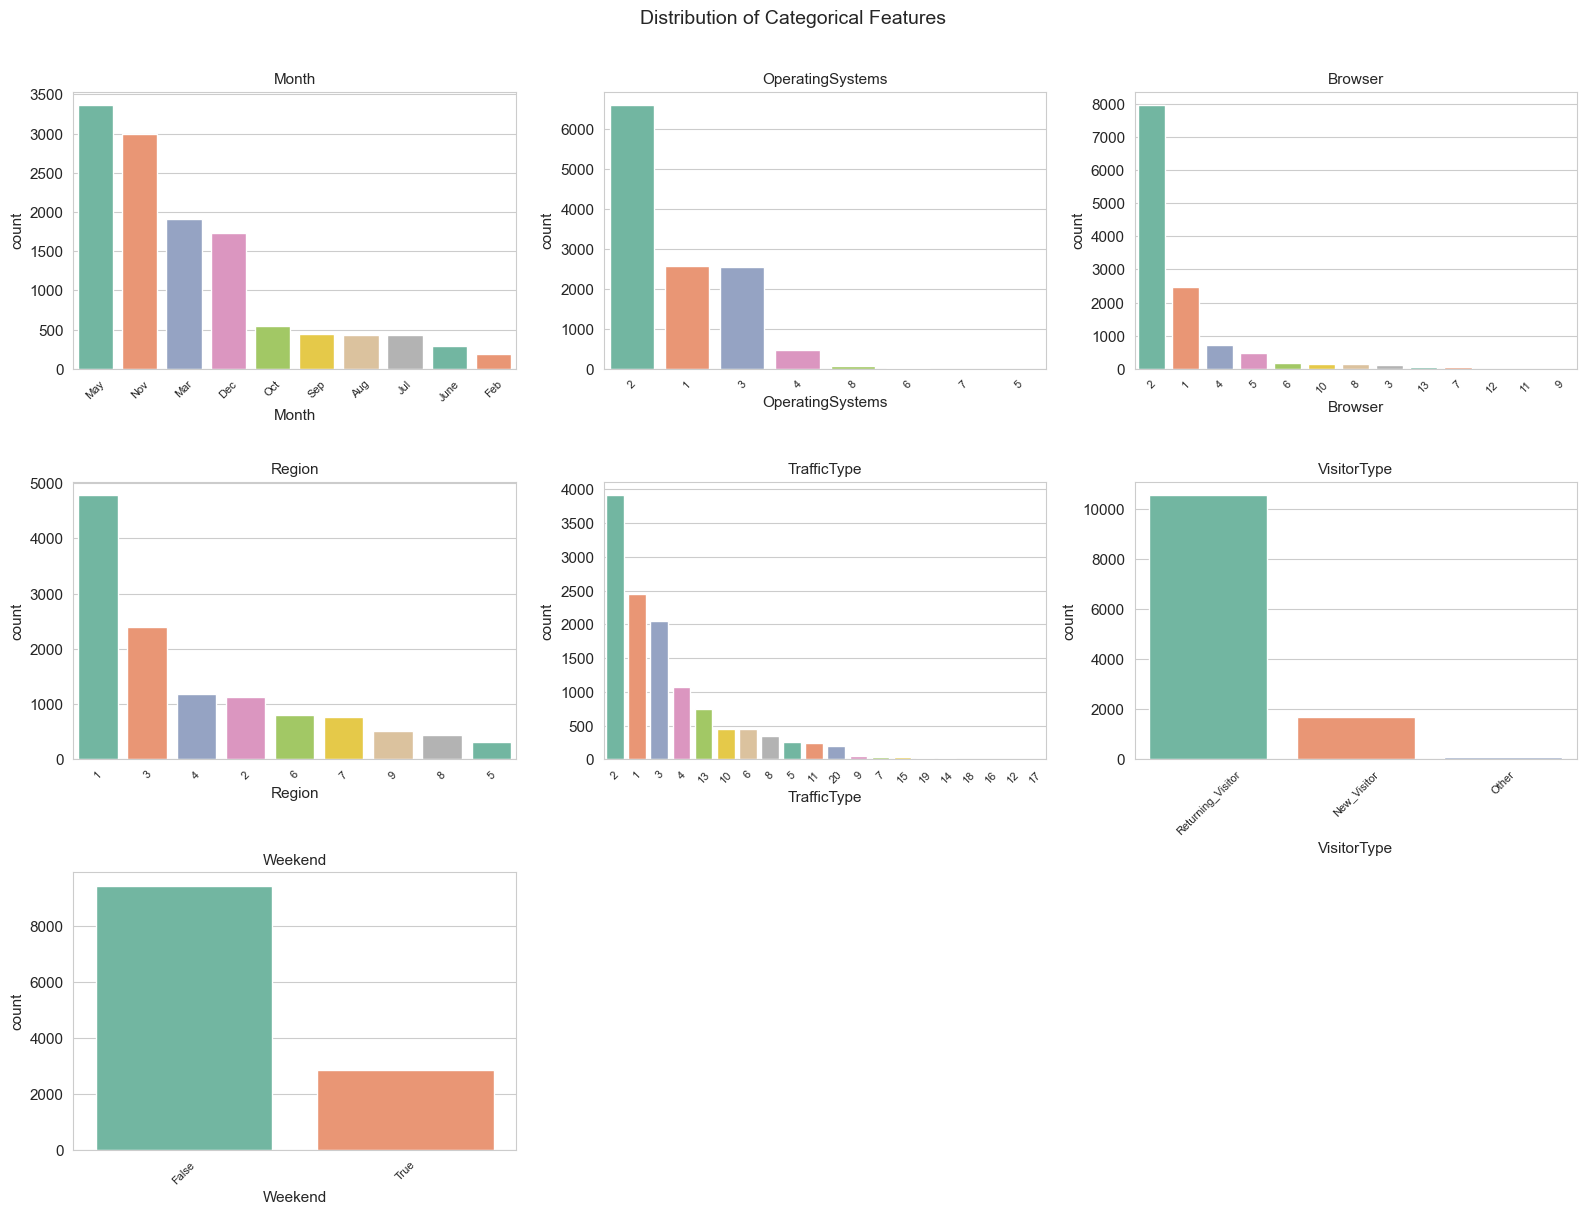

In [8]:
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region',
                    'TrafficType', 'VisitorType', 'Weekend']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.5 Correlation Analysis

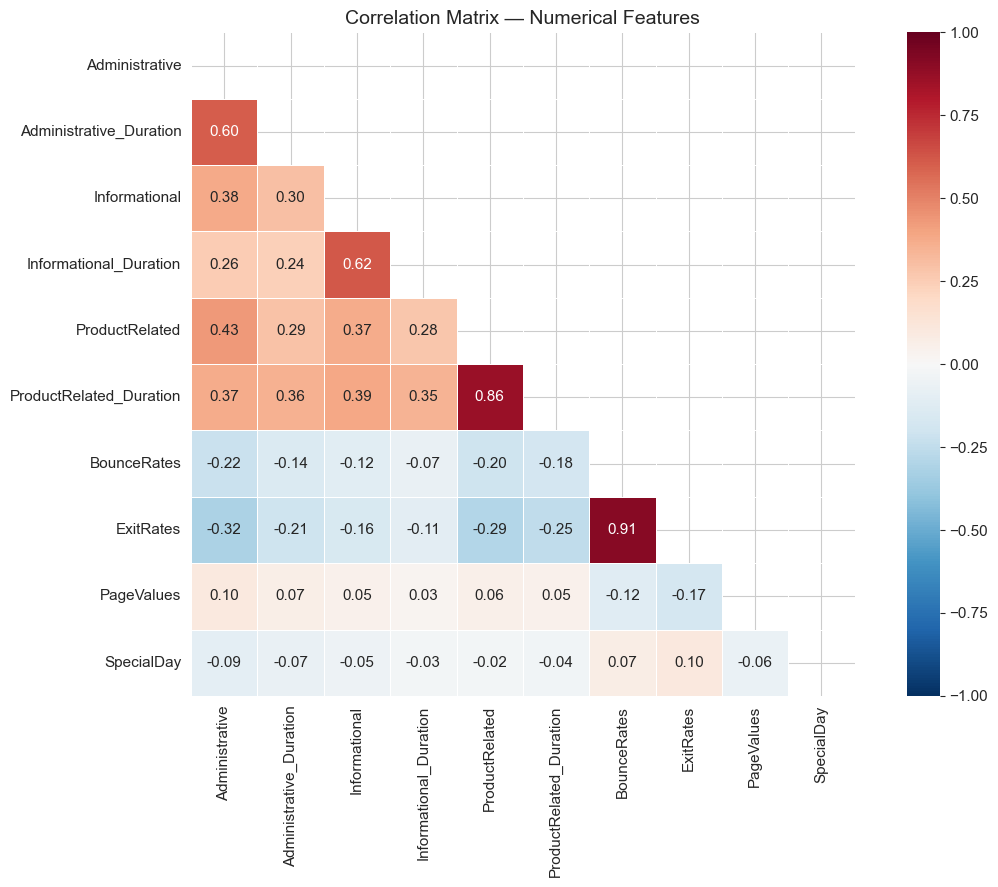

In [9]:
# Correlation heatmap for numerical features
corr = df[numerical_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

## 1.6 Feature-Target Relationships

/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/3224923282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i],
/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/3224923282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i],
/var/folders/q_/3w13lnb54m51nvny_pykyk580000gn/T/ipykernel_40910/3224923282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i],
/var/folders/q_/3w13lnb54m51nvny_pykyk58

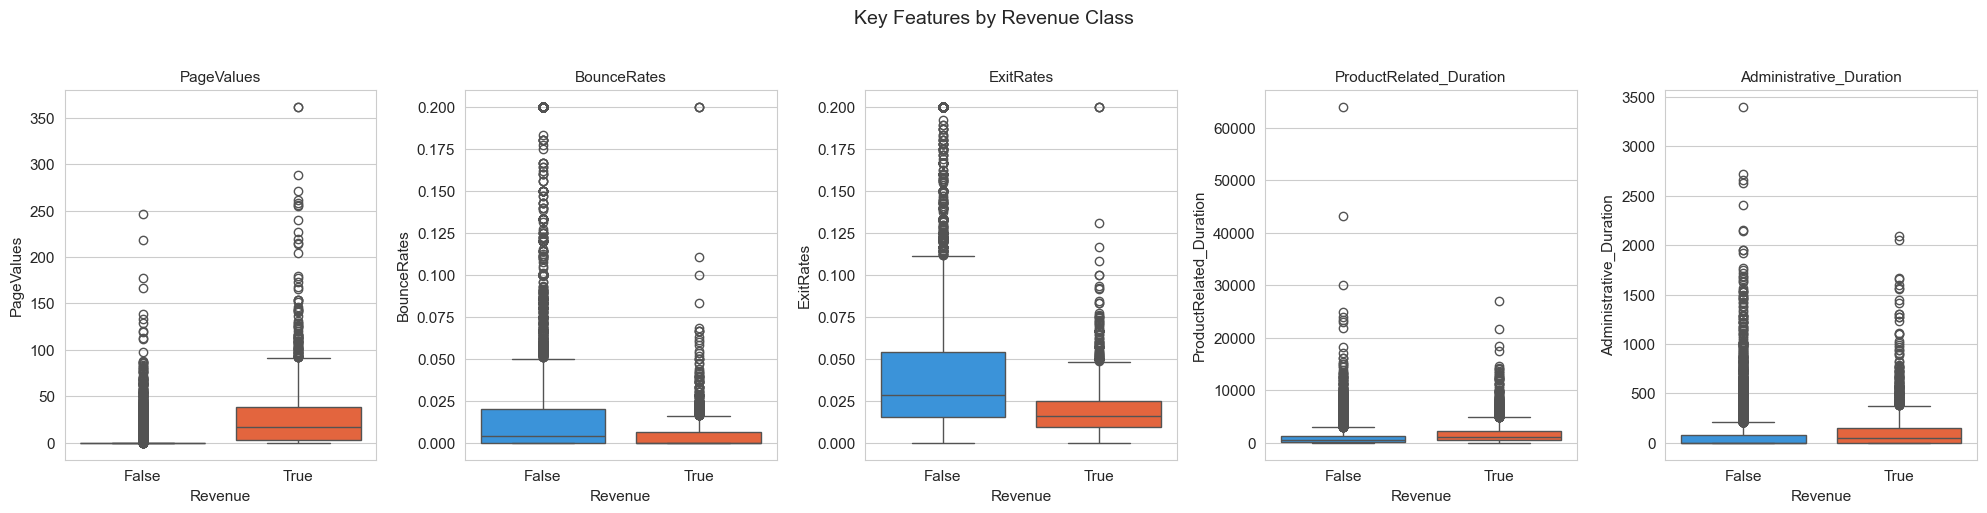

In [10]:
# Key features for boxplot comparison
key_features = ['PageValues', 'BounceRates', 'ExitRates',
                'ProductRelated_Duration', 'Administrative_Duration']

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i],
                palette=['#2196F3', '#FF5722'])
    axes[i].set_title(col, fontsize=11)

fig.suptitle('Key Features by Revenue Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

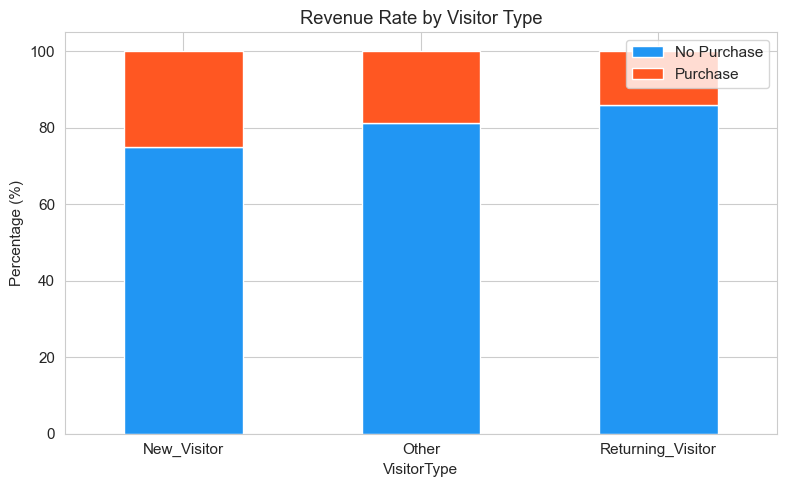

In [11]:
# Visitor type vs revenue
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=ax, color=['#2196F3', '#FF5722'])
ax.set_title('Revenue Rate by Visitor Type')
ax.set_ylabel('Percentage (%)')
ax.legend(['No Purchase', 'Purchase'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1.7 Key Observations

- **Class imbalance**: ~84.5% of sessions do not result in a purchase — SMOTE will be needed during training.
- **PageValues** is the strongest discriminator, sessions with higher page values are much more likely to convert.
- **BounceRates** and **ExitRates** are negatively correlated with purchases.
- **ProductRelated** and **ProductRelated_Duration** are the most visited page types.
- **Returning visitors** dominate the dataset but have lower conversion rates than new visitors.
- Numerical features are heavily **right-skewed**, StandardScaler will help normalize them.
- No missing values were found, simplifying the preprocessing pipeline.